# ABLATION_TFT_RFR_C1

Ablation row `+ C1 (KL loss)` of Table 4. Granger matrix ON, C1 ON, C2/C3 OFF.

**Reference paper:** *Causal-Guided Temporal Fusion Transformer for Downscaling Terrestrial Water Storage data: Case of the Tensift River Basin, Morocco* (ACM MM '26).

---

## How to run this notebook

1. **Data.** Place the input data in your Google Drive under a single folder (default expected: `MyDrive/Project_Tensift/`). Required layout (see the paper, Table 1):

   ```
   Project_Tensift/
   ├── TWS_GLDAS_Clipped/          # NASA/GLDAS/V022/CLSM/G025/DA1D, daily, 0.25°
   ├── CHIRPS_GEE_Clipped/         # UCSB-CHG/CHIRPS/DAILY, daily, 0.05°
   ├── MODIS_NDVI_GEE_Clipped/     # MODIS/061/MOD13Q1, 16-day, 250 m
   ├── MODIS_ET_GEE_Clipped/       # MODIS/061/MOD16A2GF, 8-day, 500 m
   ├── Slope_Tensift.tif           # from SRTM DTM (static)
   └── Tensift.shp                 # basin boundary shapefile (+ .shx, .dbf, .prj)
   ```

2. **Runtime.** For any TFT-based notebook (main pipeline, ablations, standalone TFT), switch to a **GPU runtime** in Colab (*Runtime → Change runtime type → T4 GPU*). Tree-based SOTA (RFR/XGBoost/LightGBM/SVR) run fine on CPU.

3. Run the cells below in order.


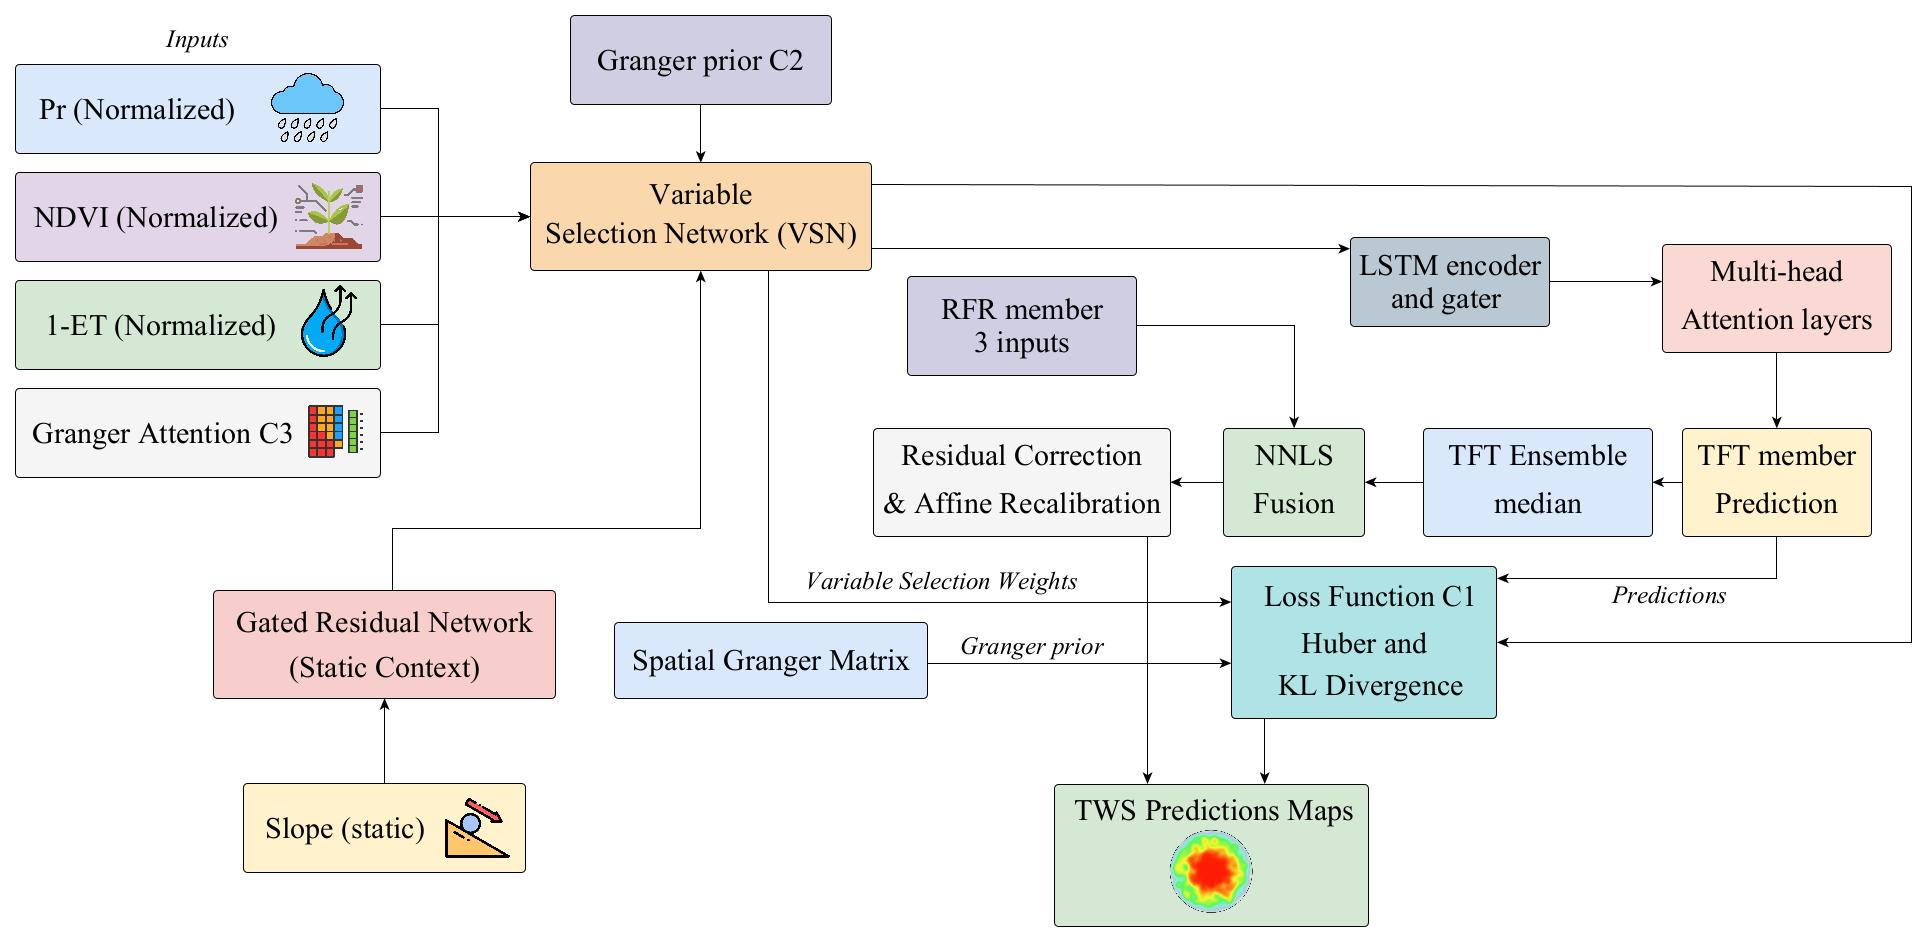![Causal-Guided TFT workflow](attachment:workflow.jpg)

*Figure 5 of the paper — overall workflow of the causal-guided TFT.*


In [ ]:
# 1. Install dependencies
!pip install --quiet torch scikit-learn statsmodels rasterio


In [ ]:
# 2. Mount Google Drive (where the Tensift data lives)
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
# 3. Clone the repository (contains all source modules)
!git clone https://github.com/BOUTAYEBAnasse/causal-guided-tft-tws /content/repo 2>/dev/null || (cd /content/repo && git pull)

import sys
sys.path.insert(0, '/content/repo/src')


In [ ]:
# 4. Point the pipeline at your data folder in Drive
# -----------------------------------------------------------------------------
# Change DATA_ROOT to wherever you uploaded the Tensift dataset.
import os
DATA_ROOT = '/content/drive/MyDrive/Project_Tensift'

# Patch causal_tft_pipeline constants BEFORE any downstream module imports them.
import causal_tft_pipeline as base
base.BASE_DIR    = DATA_ROOT
base.NAME_FILE   = os.path.join(DATA_ROOT, 'name_files_GRSL_TWS.txt')
base.OUT_DIR     = os.path.join(DATA_ROOT, 'results_ABLATION_TFT_RFR_C1')
base.TENSIFT_SHP = os.path.join(DATA_ROOT, 'Tensift.shp')
os.makedirs(base.OUT_DIR, exist_ok=True)

print('BASE_DIR   :', base.BASE_DIR)
print('OUT_DIR    :', base.OUT_DIR)
print('TENSIFT_SHP:', base.TENSIFT_SHP)


In [ ]:
# 5. Run the pipeline
from ABLATION_TFT_RFR_C1 import main
main()


---

## Outputs

- Downscaled TWS maps (`SR_TWS_YYYYMMDD.tif`, 0.05°, WGS84) written to `<OUT_DIR>/..._MAPS/`.
- Metrics printed to the notebook: RMSE, R², Pearson *r*, sub-grid variance σ̄ (Eq. 24 of the paper).
- Comparison with the reference tables of the paper (Tables 3 and 4) is documented in the repo `README.md`.
